In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from datasets import load_dataset

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
import urllib.request
import zipfile
import os

url = "https://huggingface.co/datasets/Genius-Society/HEp2/resolve/main/data.zip"
urllib.request.urlretrieve(url, "hep2_data.zip")

with zipfile.ZipFile("hep2_data.zip", "r") as zip_ref:
    zip_ref.extractall("hep2_data")

print("Downloaded and extracted successfully.")

Downloaded and extracted successfully.


In [4]:
import os

for root, dirs, files in os.walk("hep2_data"):
    level = root.replace("hep2_data", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

    for file in files[:10]:
        print(f"{indent}    {file}")

hep2_data/
    data/
        Centromere/
        Golgi/
        Homogeneous/
        Nucleolar/
        NuMem/
        Speckled/


In [5]:
import os

data_dir = "hep2_data/data"

class_counts = {}

for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

        class_counts[class_name] = count

print("HEp-2 Class Distribution:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

print(f"\nTotal images: {sum(class_counts.values())}")

HEp-2 Class Distribution:

Centromere: 2741
Golgi: 724
Homogeneous: 2494
NuMem: 2208
Nucleolar: 2598
Speckled: 2831

Total images: 13596


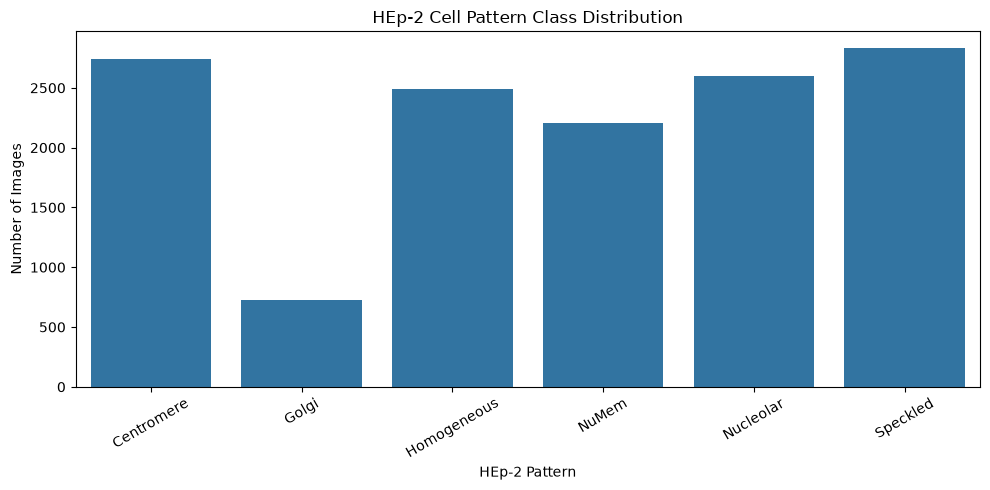

In [6]:
# ==========================================================
# Visualize Class Distribution
# ----------------------------------------------------------
# Purpose:
# Visualize the number of images in each HEp-2 staining
# pattern class.
#
# Why?
# The visualization helps identify class imbalance before
# preprocessing and model training.
# ==========================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.title("HEp-2 Cell Pattern Class Distribution")
plt.xlabel("HEp-2 Pattern")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

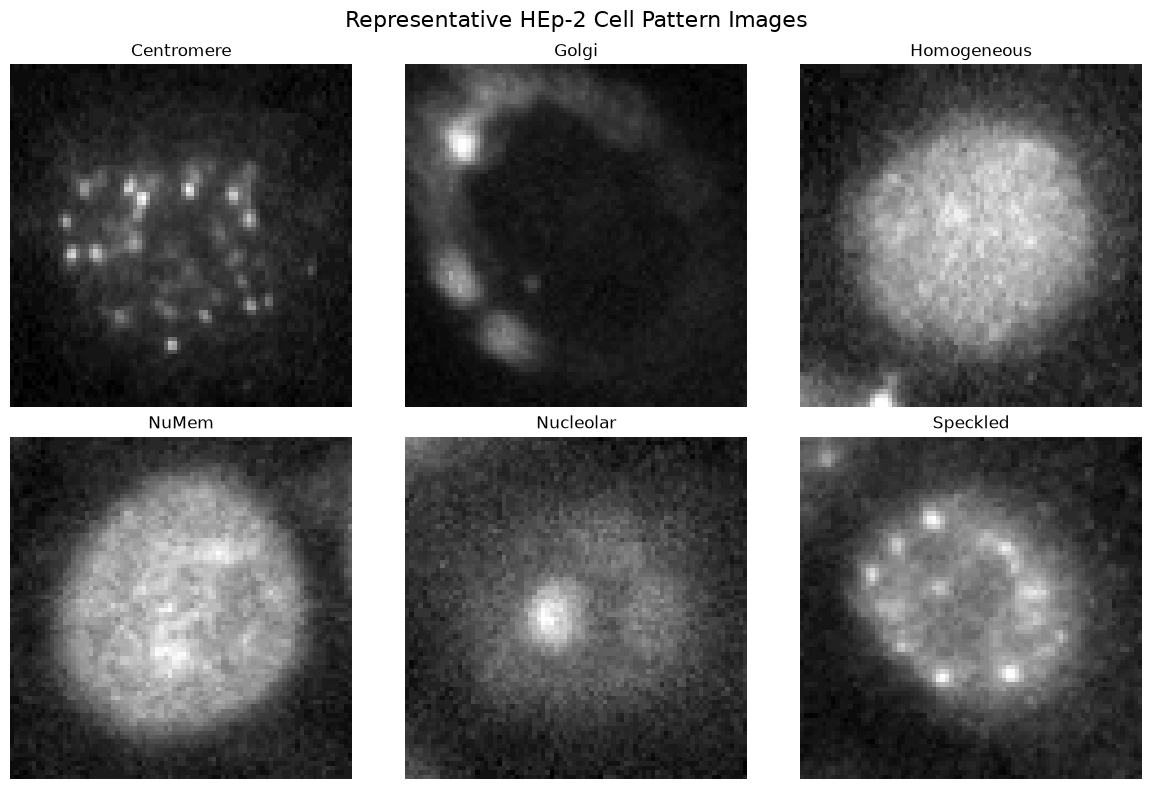

In [7]:
# ==========================================================
# Visualize Representative Images
# ----------------------------------------------------------
# Purpose:
# Display representative HEp-2 cell images from each of
# the six staining-pattern classes.
#
# Why?
# Visual inspection helps us understand the visual
# characteristics of each HEp-2 pattern before preprocessing
# and model training.
# ==========================================================

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, class_name in zip(axes.flat, sorted(class_counts.keys())):

    class_path = os.path.join(data_dir, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    image_path = os.path.join(class_path, image_files[0])

    image = Image.open(image_path)

    ax.imshow(image, cmap="gray")
    ax.set_title(class_name)
    ax.axis("off")

plt.suptitle("Representative HEp-2 Cell Pattern Images", fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# Analyze Image Dimensions
# ----------------------------------------------------------
# Purpose:
# Determine the dimensions of the HEp-2 cell images.
#
# Why?
# Image dimensions are important for deciding the resizing
# required before feeding images into the CNN models.
# ==========================================================

image_sizes = []

for class_name in sorted(class_counts.keys()):

    class_path = os.path.join(data_dir, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    for file_name in image_files:
        image_path = os.path.join(class_path, file_name)

        with Image.open(image_path) as image:
            image_sizes.append(image.size)

unique_sizes = Counter(image_sizes)

print("Image dimensions found in the dataset:\n")

for size, count in unique_sizes.items():
    print(f"{size}: {count} images")

Image dimensions found in the dataset:

(78, 78): 13596 images


In [9]:
# ==========================================================
# Analyze Image Color Format
# ----------------------------------------------------------
# Purpose:
# Determine whether the HEp-2 images are grayscale, RGB,
# or another image format.
#
# Why?
# The CNN backbones used in this project expect 3-channel
# image input, so this information is important for the
# preprocessing pipeline.
# ==========================================================

image_modes = Counter()

for class_name in sorted(class_counts.keys()):

    class_path = os.path.join(data_dir, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    for file_name in image_files:
        image_path = os.path.join(class_path, file_name)

        with Image.open(image_path) as image:
            image_modes[image.mode] += 1

print("Image color modes found:\n")

for mode, count in image_modes.items():
    print(f"{mode}: {count} images")

Image color modes found:

L: 13596 images


Pixel intensity information:
Minimum intensity: 0
Maximum intensity: 255
Mean intensity: 38.03
Standard deviation: 28.83


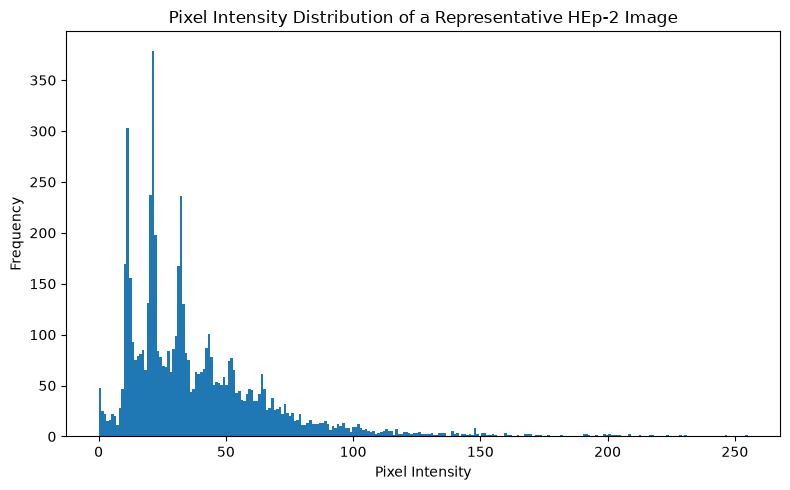

In [10]:
# ==========================================================
# Analyze Pixel Intensity Distribution
# ----------------------------------------------------------
# Purpose:
# Examine the grayscale pixel intensity values of the
# HEp-2 images.
#
# Why?
# Understanding the intensity range helps us determine the
# nature of the image data before normalization and other
# preprocessing operations.
# ==========================================================

sample_image_path = os.path.join(
    data_dir,
    sorted(class_counts.keys())[0],
    os.listdir(
        os.path.join(data_dir, sorted(class_counts.keys())[0])
    )[0]
)

sample_image = Image.open(sample_image_path).convert("L")
pixel_values = np.array(sample_image)

print("Pixel intensity information:")
print(f"Minimum intensity: {pixel_values.min()}")
print(f"Maximum intensity: {pixel_values.max()}")
print(f"Mean intensity: {pixel_values.mean():.2f}")
print(f"Standard deviation: {pixel_values.std():.2f}")

plt.figure(figsize=(8, 5))
plt.hist(pixel_values.flatten(), bins=256)
plt.title("Pixel Intensity Distribution of a Representative HEp-2 Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [11]:
# ==========================================================
# EDA Summary
# ----------------------------------------------------------
# Dataset:
# HEp-2 cell images with six staining-pattern classes.
#
# Key Findings:
# - Total images: 13,596
# - Image size: 78 × 78 pixels
# - Image format: Grayscale
# - Pixel intensity range: 0–255
# - Class distribution is imbalanced, particularly for Golgi.
#
# Preprocessing Requirements:
# - Resize images to the CNN input size.
# - Convert grayscale images to 3-channel format.
# - Normalize image values.
# - Create training, validation, and test sets.
#
# These steps prepare the dataset for ResNet50 and
# DenseNet121 model development and subsequent Grad-CAM
# interpretability analysis.
# ==========================================================

print("EDA completed successfully.")
print("Ready to proceed with preprocessing.")

EDA completed successfully.
Ready to proceed with preprocessing.
